# Google Play Store dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:/Users/Prem/Decodelabs/googleplaystore/data/googleplaystore.csv')
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [2]:
df.head(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167,5.6M,"50,000+",Free,0,Everyone,Art & Design,"March 26, 2017",1.0,2.3 and up
6,Smoke Effect Photo Maker - Smoke Editor,ART_AND_DESIGN,3.8,178,19M,"50,000+",Free,0,Everyone,Art & Design,"April 26, 2018",1.1,4.0.3 and up
7,Infinite Painter,ART_AND_DESIGN,4.1,36815,29M,"1,000,000+",Free,0,Everyone,Art & Design,"June 14, 2018",6.1.61.1,4.2 and up
8,Garden Coloring Book,ART_AND_DESIGN,4.4,13791,33M,"1,000,000+",Free,0,Everyone,Art & Design,"September 20, 2017",2.9.2,3.0 and up
9,Kids Paint Free - Drawing Fun,ART_AND_DESIGN,4.7,121,3.1M,"10,000+",Free,0,Everyone,Art & Design;Creativity,"July 3, 2018",2.8,4.0.3 and up


In [3]:
df.shape

(10841, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Rating,9367.0,4.193338,0.537431,1.0,4.0,4.3,4.5,19.0


In [6]:
df_original_shape = df.shape
df_original_shape

(10841, 13)

### I got 483 duplicated rows in total, so we'll drop them from the dataset.

In [7]:
df.duplicated().sum()

np.int64(483)

In [8]:
df.drop_duplicates(inplace=True)

### Since the datatype for column "Reviews" is wrong, I changed the datatype to numeric (float or integer). 

In [9]:
df['Reviews'].dtype

dtype('O')

### While changing the datatype of "Reviews" i got corrupted row with index=10472 which has everything wrong in them like category, installs, price etc.
### So, i droped it from the dataset.

In [10]:
df['Reviews']=pd.to_numeric(df['Reviews'], errors='coerce')

In [11]:
df[df['Reviews'].isnull()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,NaN,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [12]:
df.drop(10472, inplace=True)

### Datatype changed from 'object' to 'float'

In [13]:
df['Reviews'].dtype

dtype('float64')

### The column "Installs" has also wrong datatype and has symbols like "+" and "," so i removed all the symbols and convert the datatype to integer.

In [14]:
df['Installs'].dtype

dtype('O')

In [15]:
df['Installs']=df['Installs'].str.replace(',','')
df['Installs']=df['Installs'].str.replace('+','')
df['Installs']=pd.to_numeric(df['Installs'])

In [16]:
df['Installs'].dtype

dtype('int64')

In [17]:
df['Installs'].head()

0       10000
1      500000
2     5000000
3    50000000
4      100000
Name: Installs, dtype: int64

### The column "Price" has wrong datatype which is "object" and has symbol "$" so i removed the symbol and changed the datatype to Float.

In [18]:
df['Price'].dtype

dtype('O')

In [19]:
df['Price']=df['Price'].str.replace('$','')
df['Price']=pd.to_numeric(df['Price'])

In [20]:
df['Price'].dtype

dtype('float64')

### The column "Size" has also wrong datatype and contains letters "M" for MB, "k" for KB and somewhere "Varies with device" so i removed all the letters and used 1MB=1000KB formula and finally changed the datatype to Float.

In [21]:
df['Size'].dtype

dtype('O')

In [22]:
df['Size'].head()

0     19M
1     14M
2    8.7M
3     25M
4    2.8M
Name: Size, dtype: object

In [23]:
df['Size'].tail()

10836                   53M
10837                  3.6M
10838                  9.5M
10839    Varies with device
10840                   19M
Name: Size, dtype: object

In [24]:
df['Size']=df['Size'].replace('Varies with device', np.nan)

In [25]:
def convert_size(size):
    size=str(size)
    if 'M' in size:
        return float(size.replace('M',''))
    elif 'k' in size:
        return float(size.replace('k',''))/1000
    else:
        return np.nan

df['Size']=df['Size'].apply(convert_size)

In [26]:
df['Size'].dtype

dtype('float64')

In [27]:
df['Size'].tail()

10836    53.0
10837     3.6
10838     9.5
10839     NaN
10840    19.0
Name: Size, dtype: float64

### The "Last Updated" column has also wrong datatype, it should be of "datetime". 

In [28]:
df['Last Updated'].dtype

dtype('O')

In [29]:
df['Last Updated'].head()

0     January 7, 2018
1    January 15, 2018
2      August 1, 2018
3        June 8, 2018
4       June 20, 2018
Name: Last Updated, dtype: object

In [30]:
df['Last Updated']=pd.to_datetime(df['Last Updated'])

In [31]:
df['Last Updated'].dtype

dtype('<M8[ns]')

In [32]:
df['Last Updated'].head()

0   2018-01-07
1   2018-01-15
2   2018-08-01
3   2018-06-08
4   2018-06-20
Name: Last Updated, dtype: datetime64[ns]

### We have 1465 null values in "Rating", 1526 in "Size", 1 in "Type", 8 in "Current Ver" and 2 in "Android Ver".

In [33]:
df.isnull().sum()

App                  0
Category             0
Rating            1465
Reviews              0
Size              1526
Installs             0
Type                 1
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

### Filling Null values of "Rating" & "Size" by using KNN imputer (Preprocessing tool).

In [34]:
from sklearn.impute import KNNImputer

num_cols=['Rating','Size']
knn_imputer = KNNImputer(n_neighbors=2)
df[num_cols] = knn_imputer.fit_transform(df[num_cols])

### Filled Null of "Type" with "free".

In [35]:
df['Type']=df['Type'].fillna('Free')

### Filled Nulls of "Current Ver" & "Android Ver" with "Unknown".

In [36]:
df['Current Ver']=df['Current Ver'].fillna('Unknown')

In [37]:
df['Android Ver']=df['Android Ver'].fillna('Unknown')

In [38]:
df.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [39]:
df.to_csv("C:/Users/Prem/Decodelabs/googleplaystore/data/cleaned_googleplaystore.csv", index=False)

## Visualization

### Majority of apps are availiable freely.

<Axes: xlabel='count', ylabel='Type'>

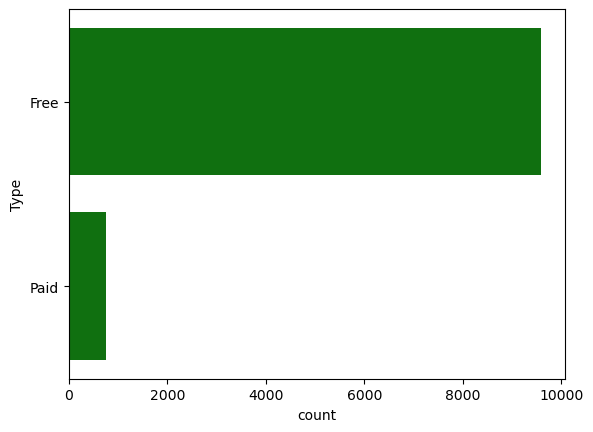

In [60]:
sns.countplot(df['Type'], color='green')

### More than 8000 apps are availiable for everyone without any age restrictions.

<Axes: xlabel='Content Rating', ylabel='count'>

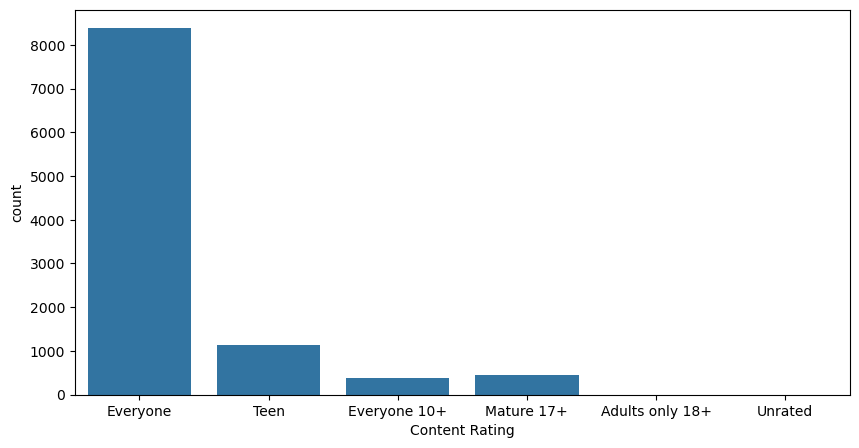

In [54]:
plt.figure(figsize=(10,5))
sns.countplot(x='Content Rating', data=df)

### Out of 10,000+ apps, more than 5,000 apps have ratings above 4.5 stars.

<Axes: xlabel='Rating', ylabel='Count'>

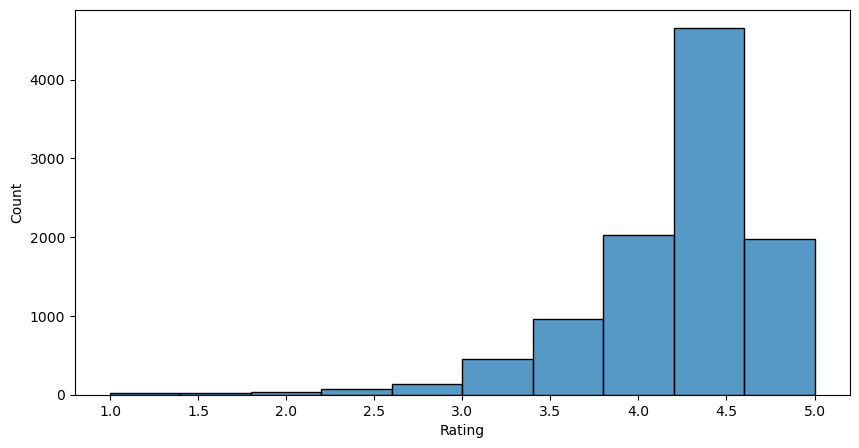

In [67]:
plt.figure(figsize=(10,5))
sns.histplot(df['Rating'], bins=10)

# Now we have a final clean dataset with zero Null values, correct datatypes, zero duplicates, ready for modelling.